# Multi-objective robust decision-making (MORDM)

This notebook describes how Multi-objective robust decision-making (MORDM) was used to find robust policies to deal with the flood risk of the IJssel river.

The approach for the MORDM consists of four steps:
1. Problem formulation
2. Searching for candidate solutions
3. Re-evaluate candidate solutions under uncertainty
4. Performing a scenario discovery

These four steps are based on 'assignment 9 - MORDM' of the course EPA141A: https://github.com/quaquel/epa141A_open/tree/master/Week%205-6%20-%20robustness%20and%20direct%20search

#### Onthoud!
Jupyter notebooks stimulate the use of a literate computing workflow. This means that you
can interleave code, its outputs, text, and latex-style equations. Ideally, when sharing
notebooks with others, it allows you to follow along with their thinking. Prior to any code,
there should be readable text motivating the code that is to follow and any pointers for
understanding the code. Next, the code is given with possible inline comments for further
readability. Next, the output of the code is shown as a figure or table. This is followed by text
interpreting these results: what does it mean or imply? Often a given result gives rise to new
thoughts, questions, or threats to validity. To address these, a next analysis step is used. (Uit de Project beschrijving)

## Step 1: Problem formulation

First, the model is imported as dike_model using problem formulation 2. Meaning that the outcomes of the model are: ....

For the optimization, the outcomes have a direction in which they are optimized (minimize or maximize). The default of the model is to minimize for all five outcomes. However, for the Environmental interest group minimizing the costs for rfr is not a strict requirement. To take their interests into account, rfr outcome is set as an info variable. Later, in step XXXX rfr costs are added as a constraint to ensure that the projects won't be extremely expensive which would decrease support of other actors.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


# Import EMA Workbench for exploratory modelling and analysis
from ema_workbench import (Policy, ema_logging, MultiprocessingEvaluator, save_results, Scenario, Constraint,
                            ScalarOutcome, Constant, perform_experiments)

from problem_formulation import get_model_for_problem_formulation

from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.em_framework.samplers import sample_uncertainties

from ema_workbench.em_framework.optimization import (HyperVolume, EpsilonProgress, ArchiveLogger, to_problem)
from ema_workbench.analysis import parcoords

from collections import OrderedDict

from ema_workbench.util.utilities import (save_results, load_results)
from ema_workbench.analysis import prim

In [2]:
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [3]:
# Check the directions the variables are optimizing to
for outcome in dike_model.outcomes:
    print(f"Outcome: {outcome.name}, Direction: {outcome.kind}")

Outcome: Expected Annual Damage, Direction: -1
Outcome: Dike Investment Costs, Direction: -1
Outcome: RfR Investment Costs, Direction: -1
Outcome: Evacuation Costs, Direction: -1
Outcome: Expected Number of Deaths, Direction: -1


## Step 2: Searching for candidate solutions

To search for candidate solutions three reference scenarios have been created. These reference scenarios are used for XXX.



### Defining reference scenarios

To increase the robustness in the search phase, the optimization will be run for three different scenarios. One with the mean values for the uncertainties, one representing a best case... and a worst case.
The best and worst case reference scenarios are based on the results from the open exploration

In [4]:
reference_scenario_mean = Scenario('reference_mean', **{'discount rate 0': 2.5, 'discount rate 1': 2.5, 'discount rate 2': 2.5, 'A.0_ID flood wave shape': 75,
                                              'A.1_Bmax': 190, 'A.1_pfail': 0.5, 'A.1_Brate': 1.5,
                                              'A.2_Bmax': 190, 'A.2_pfail': 0.5, 'A.2_Brate': 1.5,
                                              'A.3_Bmax': 190, 'A.3_pfail': 0.5, 'A.3_Brate': 1.5,
                                              'A.4_Bmax': 190, 'A.4_pfail': 0.5, 'A.4_Brate': 1.5,
                                              'A.5_Bmax': 190, 'A.5_pfail': 0.5, 'A.5_Brate': 1.5})

In [22]:
# import data from open exploration - best case
with open("reference_uncertainties_rfr_only.pkl", "rb") as f:
    min_rfr_uncertainties_df = pickle.load(f)
rfr_reference = min_rfr_uncertainties_df.iloc[0]

In [24]:
# Create the best case reference scenario based on open exploration results
ordered_reference_values_best = OrderedDict([
    ('discount rate 0', rfr_reference['discount rate 0']),
    ('discount rate 1', rfr_reference['discount rate 1']),
    ('discount rate 2', rfr_reference['discount rate 2']),
    ('A.0_ID flood wave shape', rfr_reference['A.0_ID flood wave shape']),
    ('A.1_Bmax', rfr_reference['A.1_Bmax']),
    ('A.1_pfail', rfr_reference['A.1_pfail']),
    ('A.1_Brate', rfr_reference['A.1_Brate']),
    ('A.2_Bmax', rfr_reference['A.2_Bmax']),
    ('A.2_pfail', rfr_reference['A.2_pfail']),
    ('A.2_Brate', rfr_reference['A.2_Brate']),
    ('A.3_Bmax', rfr_reference['A.3_Bmax']),
    ('A.3_pfail', rfr_reference['A.3_pfail']),
    ('A.3_Brate', rfr_reference['A.3_Brate']),
    ('A.4_Bmax', rfr_reference['A.4_Bmax']),
    ('A.4_pfail', rfr_reference['A.4_pfail']),
    ('A.4_Brate', rfr_reference['A.4_Brate']),
    ('A.5_Bmax', rfr_reference['A.5_Bmax']),
    ('A.5_pfail', rfr_reference['A.5_pfail']),
    ('A.5_Brate', rfr_reference['A.5_Brate'])
])

In [7]:
# import data from open exploration - worst case
# Minimum of deaths of the worst case scenario with all dike posibilities, and no rfr
with open("reference_uncertainties_dikes_only.pkl", "rb") as f:
    min_dike_uncertainties_df = pickle.load(f)
worst_reference = min_dike_uncertainties_df.iloc[0]

In [23]:
# Create the worst case reference scenario based on open exploration results
ordered_reference_values_worst = OrderedDict([
    ('discount rate 0', worst_reference['discount rate 0']),
    ('discount rate 1', worst_reference['discount rate 1']),
    ('discount rate 2', worst_reference['discount rate 2']),
    ('A.0_ID flood wave shape', worst_reference['A.0_ID flood wave shape']),
    ('A.1_Bmax', worst_reference['A.1_Bmax']),
    ('A.1_pfail', worst_reference['A.1_pfail']),
    ('A.1_Brate', worst_reference['A.1_Brate']),
    ('A.2_Bmax', worst_reference['A.2_Bmax']),
    ('A.2_pfail', worst_reference['A.2_pfail']),
    ('A.2_Brate', worst_reference['A.2_Brate']),
    ('A.3_Bmax', worst_reference['A.3_Bmax']),
    ('A.3_pfail', worst_reference['A.3_pfail']),
    ('A.3_Brate', worst_reference['A.3_Brate']),
    ('A.4_Bmax', worst_reference['A.4_Bmax']),
    ('A.4_pfail', worst_reference['A.4_pfail']),
    ('A.4_Brate', worst_reference['A.4_Brate']),
    ('A.5_Bmax', worst_reference['A.5_Bmax']),
    ('A.5_pfail', worst_reference['A.5_pfail']),
    ('A.5_Brate', worst_reference['A.5_Brate'])
])

In [9]:
# Create a list with the three different scenarios
reference_scenarios = [reference_scenario_mean, reference_scenario_best, reference_scenario_worst]

Hier komt dan de code die uit de data van de open exploration de waardes voor de reference_scenario_worst en refernce_scenario_best haalt.

Die drie scenario's worden dan een lijst.

Met die lijst kan je dan in de optimization gaan loopen.

### Optimization
Constraints are added later on the set of possible solutions!

In [ ]:
# Convergence for 1 seed without using ArchiveLoggers for three scenarios
ema_logging.log_to_stderr(ema_logging.INFO)

convergence_metrics = [EpsilonProgress()]
nfe = 10
epsilon = [0.25] * len(dike_model.outcomes)


with MultiprocessingEvaluator(dike_model) as evaluator:
    for i, scenario in enumerate(reference_scenarios):
        results = evaluator.optimize(
            nfe=nfe,
            searchover='levers',
            epsilons=epsilon,
            convergence=convergence_metrics,
            reference=scenario
        )
        with open(f"results_{scenario.name}.pkl", "wb") as f:
            pickle.dump(results, f)


12 solutions were found for reference_mean
3 solutions were found for reference_best
9 solutions were found for reference_worst


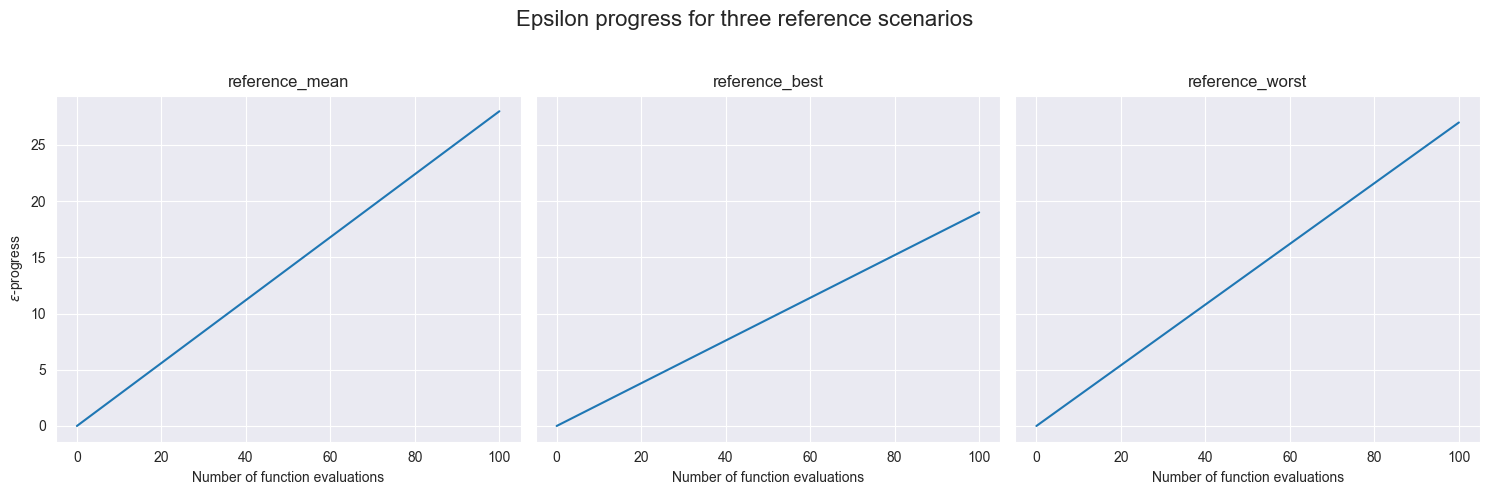

In [32]:
# Create one figure with 3 subplots in a row
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, scenario in enumerate(reference_scenarios):
    with open(f"results_{scenario.name}.pkl", "rb") as f:
        archive, convergence = pickle.load(f)

    print(len(archive), 'solutions were found for', scenario.name)

    # Plot epsilon progress for each reference scenario
    axs[i].plot(convergence.nfe, convergence.epsilon_progress)
    axs[i].set_title(scenario.name)
    axs[i].set_xlabel('Number of function evaluations')
    if i == 0:
        axs[i].set_ylabel(r'$\epsilon$-progress')


fig.suptitle('Epsilon progress for three reference scenarios', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Interpretation of figure
The epsilon progress is converging. To check whether this is also the case if different seeds are used a seed analysis is performed.

### Seed analysis
To check te number of nfe's a seed analysis is performed. The optimization is run for 5 seeds. Due to a lack of computational power we only did this seed analysis for the reference scenario with the mean values. Ideally, you would also run it for the other two.

#### Don't need to run this every time, continue at the 're-evaluate candidate solutions part!
Before running:
- clear archives
- check name of reference scenario
- set number of nfe
- set epsilon value
- set number of seeds (i in range(x))

In [85]:
results = []
convergences = []

with MultiprocessingEvaluator(dike_model) as evaluator:
    # run for 5 seeds
    for i in range(3):
        # we create 2 covergence tracker metrics
        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in dike_model.levers],
                [o.name for o in dike_model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        result, convergence = evaluator.optimize(nfe=1000, searchover='levers', epsilons=[0.25, 0.25, 0.25, 0.25, 0.25], convergence=convergence_metrics, reference=reference_scenario_mean)

        results.append(result)
        convergences.append(convergence)


[MainProcess/INFO] pool started with 18 workers
100%|██████████████████████████████████████| 1000/1000 [00:39<00:00, 25.45it/s]
[MainProcess/INFO] optimization completed, found 42 solutions
100%|██████████████████████████████████████| 1000/1000 [00:41<00:00, 23.95it/s]
[MainProcess/INFO] optimization completed, found 34 solutions
100%|██████████████████████████████████████| 1000/1000 [00:40<00:00, 24.48it/s]
[MainProcess/INFO] optimization completed, found 39 solutions
[MainProcess/INFO] terminating pool


In [86]:
# Check if this matches results of the three seeds
results

[    0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0         0        0        1        0        0        0        0        0   
 1         0        0        0        0        0        0        0        0   
 2         0        0        0        0        0        0        1        0   
 3         0        0        0        0        0        0        1        1   
 4         1        1        0        1        0        0        0        1   
 5         0        0        0        0        0        0        0        1   
 6         0        0        0        0        0        0        0        0   
 7         0        0        0        1        0        1        1        0   
 8         0        0        0        1        1        1        1        1   
 9         0        0        1        0        0        0        1        0   
 10        0        0        1        0        0        0        0        0   
 11        0        0        0        0        0    

In [87]:
# Combine both lists into a dictionary for clarity
combined_data = {
    "results": results,
    "convergences": convergences
}

# Save to one pickle file
with open("seed_analysis_3.pkl", "wb") as f:
    pickle.dump(combined_data, f)

In [88]:
with open("seed_analysis_3.pkl", "rb") as f:
    data = pickle.load(f)

results = data["results"]
convergences = data["convergences"]

In [89]:
# Check if these pickle_dump results matches results of the three seeds
results

[    0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0         0        0        1        0        0        0        0        0   
 1         0        0        0        0        0        0        0        0   
 2         0        0        0        0        0        0        1        0   
 3         0        0        0        0        0        0        1        1   
 4         1        1        0        1        0        0        0        1   
 5         0        0        0        0        0        0        0        1   
 6         0        0        0        0        0        0        0        0   
 7         0        0        0        1        0        1        1        0   
 8         0        0        0        1        1        1        1        1   
 9         0        0        1        0        0        0        1        0   
 10        0        0        1        0        0        0        0        0   
 11        0        0        0        0        0    

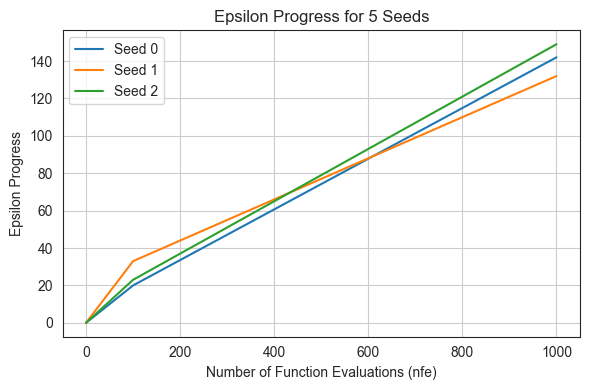

In [90]:
# Plot the epsilon progress for the different seeds
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for i, df in enumerate(convergences):
    plt.plot(df['nfe'], df['epsilon_progress'], label=f'Seed {i}')

plt.xlabel('Number of Function Evaluations (nfe)')
plt.ylabel('Epsilon Progress')
plt.title('Epsilon Progress for 5 Seeds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

It converges, so XXX nfe's (as used for the optimization is enough).

#### Interpretation of optimization
Hier komt code waarin de gevonden policies uit de drie reference scenarios samengevoegd worden. Duplicates worden verwijderd, zo eindig je met een lijst van alle potentiele policies. Die policies en outcomes gebruik je dan hieronder om het plaatje te maken.
Save deze polices met outcomes (met pickle) zodat we die verderop weer kunnen gebruiken.

To interpret the results of the optimization a Parallel coordinate plot has been created.

In [44]:
# Empty list to combine archive data frames
all_archives = []

for scenario in reference_scenarios:
    with open(f"results_{scenario.name}.pkl", "rb") as f:
        archive, convergence = pickle.load(f)

    all_archives.append(archive)

combined_archive = pd.concat(all_archives, ignore_index=True)

# Remove duplicates
combined_archive = combined_archive.drop_duplicates()

print(f"In total there are {len(combined_archive)} unique candidate solutions")

In total there are 24 unique candidate solutions


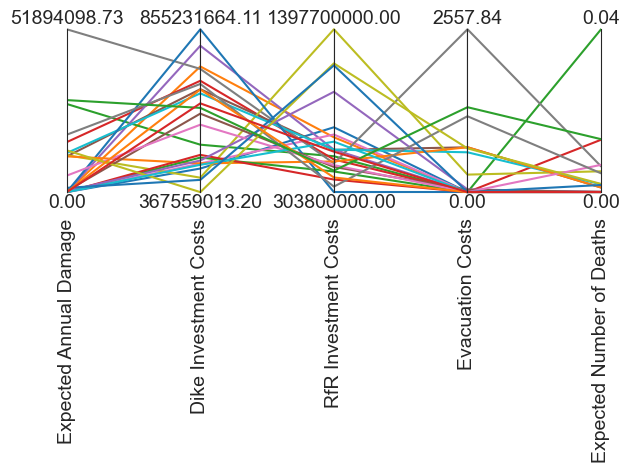

In [47]:
# Use combined archive to create parallel coordinate plot
outcomes = combined_archive.loc[:, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]]

limits = parcoords.get_limits(outcomes)
axes = parcoords.ParallelAxes(limits)
axes.plot(outcomes)

plt.show()

*Interpretation of the plot*: veel trade-offs

## Step 3: Re-evaluate candidate solutions under uncertainty
### Dit is grotendeels letterlijk gekopieerd: dus nog aanpassen!!! :))

We found a large set of candidate solutions.

Reducing the number of candidate solutions will help to reduce the number of runs we'll have to do later on. Therefore, two constraints are added that are important for the environmental interest group.

1. Minimum RfR cost: to ensure that at least two of the Room for the River projects will be part of the solution, a constraint is added which only selects solutions with RfR Investment Costs higher than 30700000+84600000. This is the price of realizing the two cheapest RfR projects: Tichelbeekse and Olburgen.
2. Minimum number of deaths: to ensure that the solutions limit the number of casaulties, this constraint only selects policies where the Expected Number of Deaths (average per year) is lower than 0.001.

In [69]:
with open("opt_search_1_seed.pkl", "rb") as f:
    data = pickle.load(f)

archive, convergence = data

In [22]:
print('Before adding constraints', len(archive), 'solutions where found')

Before adding constraints 257 solutions where found


In [23]:
# Apply constraints
logical = (archive['RfR Investment Costs'] > (30700000+84600000)) & (archive['Expected Number of Deaths'] < 0.001)

archive[logical]

policies = archive[logical]
policies = policies.drop([o.name for o in dike_model.outcomes], axis=1)

In [24]:
print('After adding constraints', len(policies), 'solutions are left')

After adding constraints 19 solutions are left


To re-evaluate the candidate solutions, they will each be run for 1000 scenarios.

In [25]:
policies_to_evaluate = []

for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))
    
n_scenarios = 100 # change to 1000 later
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

100%|██████████████████████████████████████| 1900/1900 [01:53<00:00, 16.74it/s]


In [26]:
save_results(results, 're_evaluation.tar.gz')

### Robustness
Use results to evaluate robustness. We've used the following two robustness metrics: max regret and 90th percentile max regret.


##### Max Regret

In [70]:
def calculate_regret(data, best):
    return np.abs(best-data)

In [71]:
experiments, outcomes = load_results('re_evaluation.tar.gz')

overall_regret = {}
max_regret = {}
for outcome in dike_model.outcomes:
    policy_column = experiments['policy']
    
    # create a DataFrame with all the relevent information
    # i.e., policy, scenario_id, and scores
    data = pd.DataFrame({outcome.name: outcomes[outcome.name], 
                         "policy":experiments['policy'],
                         "scenario":experiments['scenario']})
    
    # reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')
    
    # flatten the resulting hierarchical index resulting from 
    # pivoting, (might be a nicer solution possible)
    data.columns = data.columns.get_level_values(1)
    
    # we need to control the broadcasting. 
    # max returns a 1d vector across scenario id. By passing
    # np.newaxis we ensure that the shape is the same as the data
    # next we take the absolute value
    #
    # basically we take the difference of the maximum across 
    # the row and the actual values in the row
    #
    outcome_regret = (data.max(axis=1).values[:, np.newaxis] - data).abs()
    
    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()
    

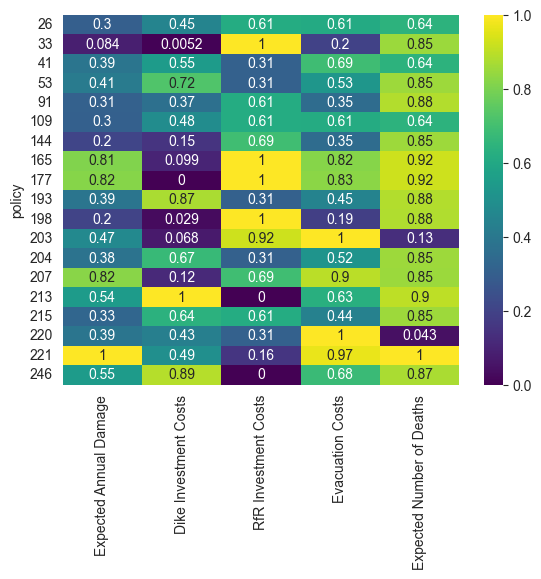

In [72]:
import seaborn as sns

max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret/max_regret.max(), cmap='viridis', annot=True)
plt.show()

In [77]:
experiments[experiments['policy']==213]

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
1400,44,131.806994,1.0,0.638028,222.423537,1.5,0.726877,296.043008,1.5,0.718555,...,0,0,0,0,0,0,0,0,213,dikesnet
1401,59,329.724113,1.5,0.551746,314.206473,10.0,0.116571,253.776400,1.0,0.977345,...,0,0,0,0,0,0,0,1,213,dikesnet
1402,113,168.019543,1.0,0.255027,332.781546,1.0,0.344398,212.653821,10.0,0.053310,...,0,0,0,0,0,0,0,2,213,dikesnet
1403,25,323.251171,1.0,0.715831,37.243830,1.0,0.186127,32.524626,1.5,0.943001,...,0,0,0,0,0,0,0,3,213,dikesnet
1404,124,318.775873,1.0,0.842847,179.525861,1.5,0.468628,189.068797,1.5,0.990415,...,0,0,0,0,0,0,0,4,213,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,130,257.164913,1.5,0.323781,230.914249,1.5,0.786948,348.842150,10.0,0.324036,...,0,0,0,0,0,0,0,95,213,dikesnet
1496,33,64.151431,1.5,0.979874,320.393211,1.5,0.378441,60.866703,1.5,0.441957,...,0,0,0,0,0,0,0,96,213,dikesnet
1497,39,273.159274,1.0,0.395257,342.577013,1.5,0.267188,315.544814,1.5,0.303858,...,0,0,0,0,0,0,0,97,213,dikesnet
1498,51,127.566930,1.5,0.727620,214.072854,1.0,0.681683,131.584150,10.0,0.292253,...,0,0,0,0,0,0,0,98,213,dikesnet


IndexError: list index out of range

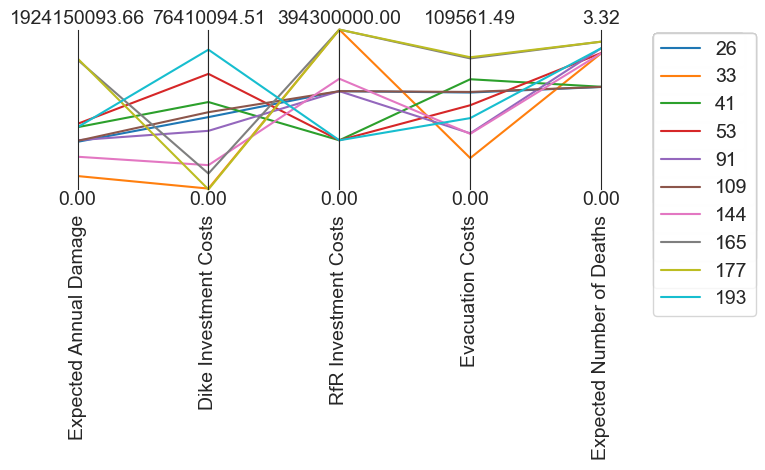

In [65]:
colors = sns.color_palette()

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot
# data['policy'] = data.index.astype("float64")

limits = parcoords.get_limits(data)
limits.loc[0, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]] = 0

paraxes = parcoords.ParallelAxes(limits)

for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
    paraxes.legend()
    
plt.show()

## 90th percentile max regret

In [50]:
results_file = "re_evaluation.tar.gz"
experiments, outcomes = load_results(results_file)

# Convert array to dataframe
outcomes_df = pd.DataFrame.from_records(outcomes)

# Define relevant columns
key_cols = ["scenario", "policy"]
outcome_names = ["Expected Annual Damage", "Expected Number of Deaths"]

# Merge selected metadata and outcomes
df = pd.concat([experiments[key_cols], outcomes_df[outcome_names]], axis=1)

# 90th percentile dictionary to store regret results
regret_90p = {}

for outcome in outcome_names:
    # Scenario × Policy matrix
    matrix = df.pivot(index="scenario", columns="policy", values=outcome)

    # Regret matrix: difference from best outcome per scenario -> for each scenario, subtract the best policy outcome
    regret = matrix.subtract(matrix.min(axis=1), axis=0)

    # Compute the 90th percentile of regret per policy
    regret_90p[outcome] = regret.quantile(0.9)

# Combine results into one datafame
regret_90p_df = pd.DataFrame(regret_90p)
print(regret_90p_df)

        Expected Annual Damage  Expected Number of Deaths
policy                                                   
26                3.065901e+08                   0.416131
33                3.595141e+08                   0.070443
41                1.399437e+08                   0.416171
53                1.824261e+08                   0.052480
91                1.112320e+08                   0.016039
109               2.064029e+08                   0.416196
144               2.175870e+08                   0.055117
165               2.079799e+08                   0.055757
177               1.674928e+08                   0.053400
193               2.069478e+08                   0.022071
198               3.253362e+08                   0.043907
203               1.763188e+08                   1.525815
204               1.791764e+08                   0.053463
207               8.321579e+07                   0.415910
213               1.482455e+08                   0.017483
215           

## Step 4: Using scenario discovery to detect the vulnerabilities of the candidate solutions and improving the candidate solutions

To analyze which combination of uncertainties results in poor perfomance, a scenario discovery is performed.

The focus is on understanding which combination of uncertainties results in ... lower/higher than XXX.

*Explain wy the focus is on this*

--> PRIM: kies welke box!

In [5]:
experiments, outcomes = load_results('re_evaluation.tar.gz')

In [6]:
outcomes

{'Expected Annual Damage': array([0.00000000e+00, 8.35284643e+07, 5.38929464e+08, ...,
        7.94618179e+08, 3.14400327e+07, 4.41148743e+07], shape=(1900,)),
 'Dike Investment Costs': array([80085003.70091854, 80085003.70091854, 80085003.70091854, ...,
        46698529.6483721 , 46698529.6483721 , 46698529.6483721 ],
       shape=(1900,)),
 'RfR Investment Costs': array([2.979e+08, 2.979e+08, 2.979e+08, ..., 5.403e+08, 5.403e+08,
        5.403e+08], shape=(1900,)),
 'Evacuation Costs': array([    0.        ,  2931.86040393, 11665.14189472, ...,
        50845.24244822,  2078.32234495,  1837.64130109], shape=(1900,)),
 'Expected Number of Deaths': array([0.        , 0.03487455, 0.2718299 , ..., 0.10101662, 0.00554752,
        0.01181168], shape=(1900,))}

In [7]:
experiments.head()

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
0,44,131.806994,1.0,0.638028,222.423537,1.5,0.726877,296.043008,1.5,0.718555,...,0,7,0,0,2,0,0,0,26,dikesnet
1,59,329.724113,1.5,0.551746,314.206473,10.0,0.116571,253.776400,1.0,0.977345,...,0,7,0,0,2,0,0,1,26,dikesnet
2,113,168.019543,1.0,0.255027,332.781546,1.0,0.344398,212.653821,10.0,0.053310,...,0,7,0,0,2,0,0,2,26,dikesnet
3,25,323.251171,1.0,0.715831,37.243830,1.0,0.186127,32.524626,1.5,0.943001,...,0,7,0,0,2,0,0,3,26,dikesnet
4,124,318.775873,1.0,0.842847,179.525861,1.5,0.468628,189.068797,1.5,0.990415,...,0,7,0,0,2,0,0,4,26,dikesnet


In [8]:
# Remove levers from experiments DataFrame
cleaned_experiments = experiments.drop(labels=[
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    '0_RfR 0', '0_RfR 1', '0_RfR 2',
    '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2',
    '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'EWS_DaysToThreat', 'policy'
], axis=1)

cleaned_experiments.head()

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.4_Brate,A.4_pfail,A.5_Bmax,A.5_Brate,A.5_pfail,discount rate 0,discount rate 1,discount rate 2,scenario,model
0,44,131.806994,1.0,0.638028,222.423537,1.5,0.726877,296.043008,1.5,0.718555,...,1.5,0.401267,328.451830,1.5,0.861130,2.5,2.5,4.5,0,dikesnet
1,59,329.724113,1.5,0.551746,314.206473,10.0,0.116571,253.776400,1.0,0.977345,...,1.5,0.227161,74.730092,1.5,0.224107,3.5,3.5,4.5,1,dikesnet
2,113,168.019543,1.0,0.255027,332.781546,1.0,0.344398,212.653821,10.0,0.053310,...,1.5,0.615305,264.084618,10.0,0.779429,1.5,2.5,3.5,2,dikesnet
3,25,323.251171,1.0,0.715831,37.243830,1.0,0.186127,32.524626,1.5,0.943001,...,1.0,0.333433,229.895807,10.0,0.698496,4.5,3.5,4.5,3,dikesnet
4,124,318.775873,1.0,0.842847,179.525861,1.5,0.468628,189.068797,1.5,0.990415,...,1.0,0.355401,299.824262,1.5,0.081180,2.5,3.5,2.5,4,dikesnet


In [44]:
y = outcomes['Expected Number of Deaths'] > 0.001  # CHOOSE RIGHT PARAMETER THING

In [47]:
# Perform PRIM analysis
prim_alg = prim.Prim(cleaned_experiments, y, threshold=0.5, peel_alpha=0.05)
box = prim_alg.find_box()

In [48]:
box.inspect_tradeoff()

# # Visualize PRIM results
# box.show_tradeoff()
# #plt.savefig('prim_tradeoff_density_coverage.png')
# plt.show()


alt.VConcatChart(...)

coverage       0.664716
density        0.949039
id             4.000000
k           1136.000000
mass           0.630000
mean           0.949039
n           1197.000000
res_dim        4.000000
Name: 4, dtype: float64

                           box 4                                     
                             min              max  qp value  qp value
A.2_Bmax               30.448443       334.072722       NaN  0.132987
discount rate 2  {1.5, 2.5, 3.5}  {1.5, 2.5, 3.5}  0.000840       NaN
A.5_Bmax               43.037597       347.115505  0.132987       NaN
A.1_Bmax               45.928431       347.341143  0.158951       NaN



C:\Users\lmvan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1.5, 2.5, 3.5}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]
C:\Users\lmvan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ema_workbench\analysis\prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{1.5, 2.5, 3.5}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]


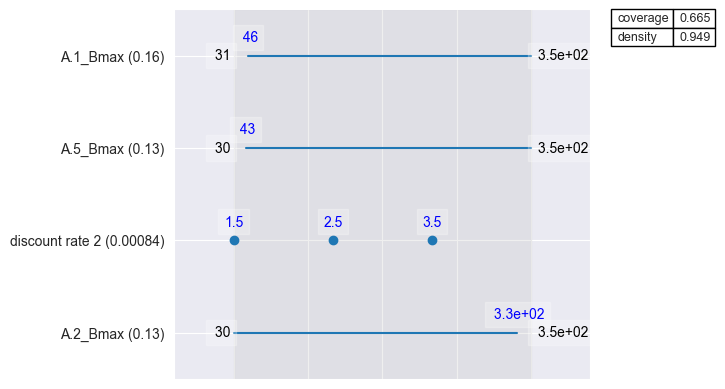

In [42]:
box.inspect(4)
box.inspect(4, style='graph')
#plt.savefig('prim_ranges_of_uncertainties.png')
plt.show()

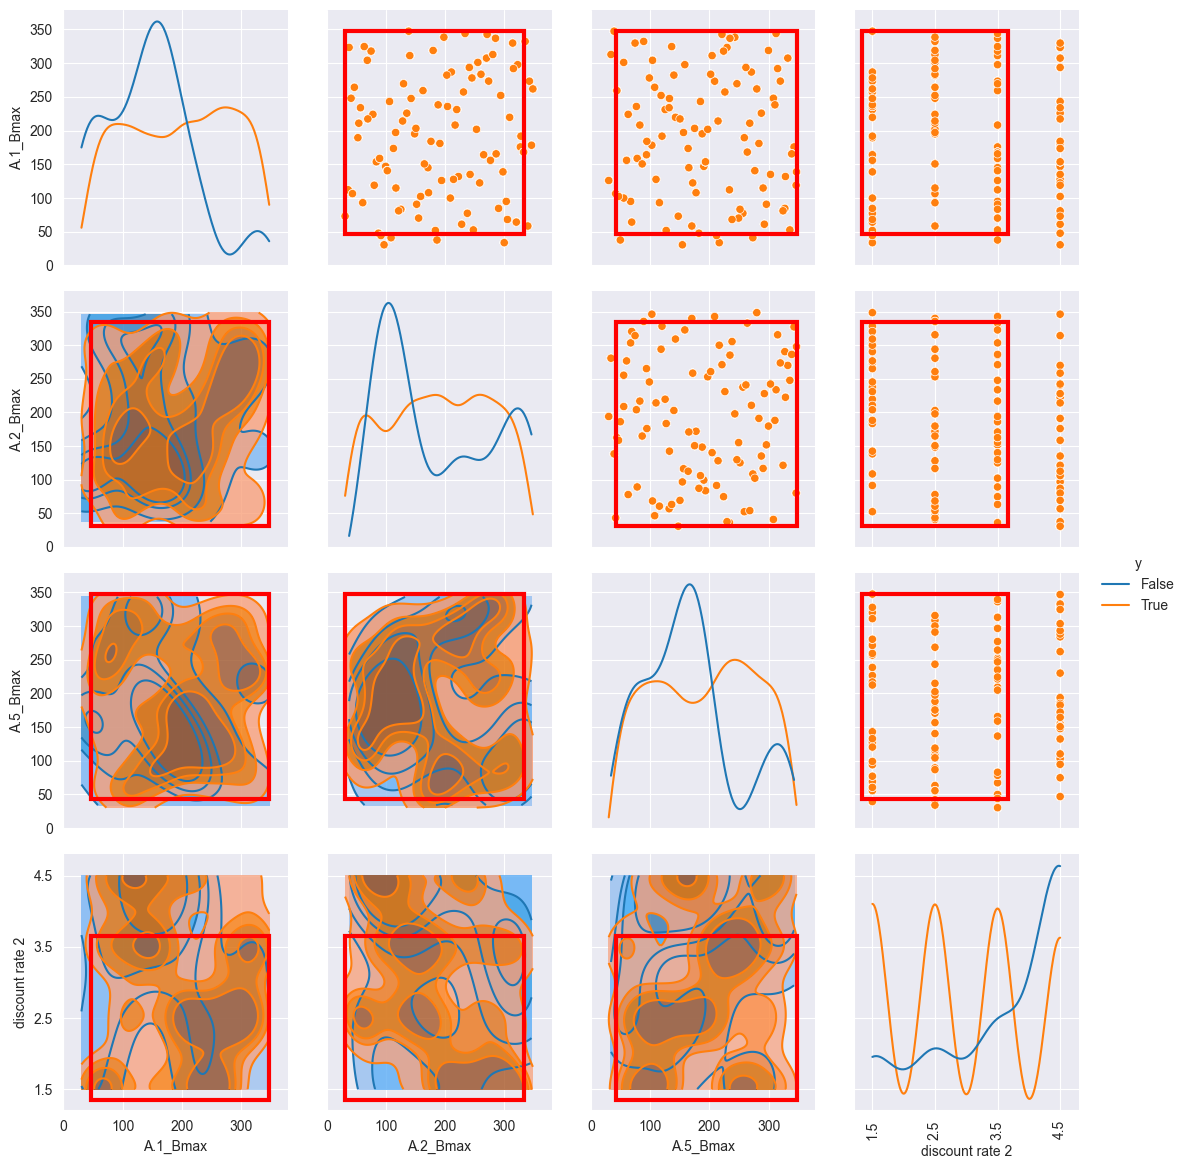

In [49]:
box.select(4)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(12, 12)
#plt.savefig('prim_scatter_plots.png')
plt.show()